In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from har_dl.definitions import get_project_root

RESULTS_DIR = Path(get_project_root()) / "data" / "results"
CLASSES = ["laying", "running", "upright-still", "walking"]

In [ ]:
overlap_results    = pd.read_csv(RESULTS_DIR / "6fcv_overlap.csv")
no_overlap_results = pd.read_csv(RESULTS_DIR / "6fcv_no_overlap.csv")

overlap_preds    = pd.read_csv(RESULTS_DIR / "6fcv_overlap_preds.csv")
no_overlap_preds = pd.read_csv(RESULTS_DIR / "6fcv_no_overlap_preds.csv")

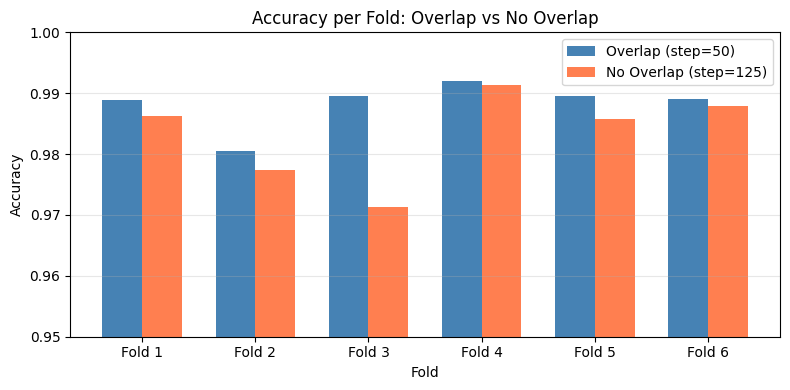

Overlap    — Mean: 0.9883 ± 0.0040
No Overlap — Mean: 0.9833 ± 0.0075


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(1, 7)
width = 0.35

ax.bar(x - width/2, overlap_results["accuracy"],    width, label="Overlap (step=50)",    color="steelblue")
ax.bar(x + width/2, no_overlap_results["accuracy"], width, label="No Overlap (step=125)", color="coral")

ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy per Fold: Overlap vs No Overlap")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in x])
ax.set_ylim(0.95, 1.0)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Overlap    — Mean: {overlap_results['accuracy'].mean():.4f} ± {overlap_results['accuracy'].std():.4f}")
print(f"No Overlap — Mean: {no_overlap_results['accuracy'].mean():.4f} ± {no_overlap_results['accuracy'].std():.4f}")

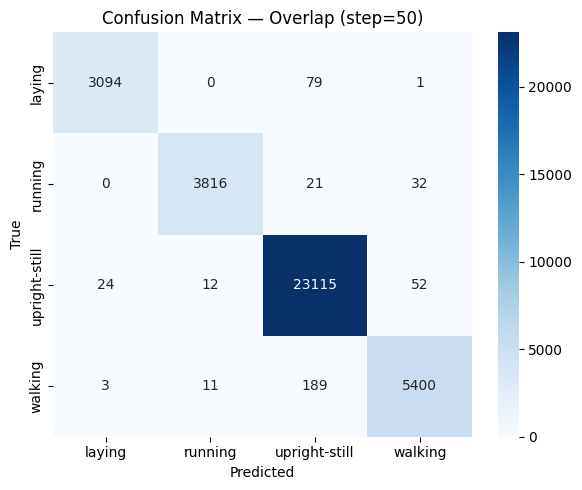

In [ ]:
cm_overlap = confusion_matrix(overlap_preds["true"], overlap_preds["pred"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_overlap, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Overlap (step=50)")
plt.tight_layout()
plt.show()

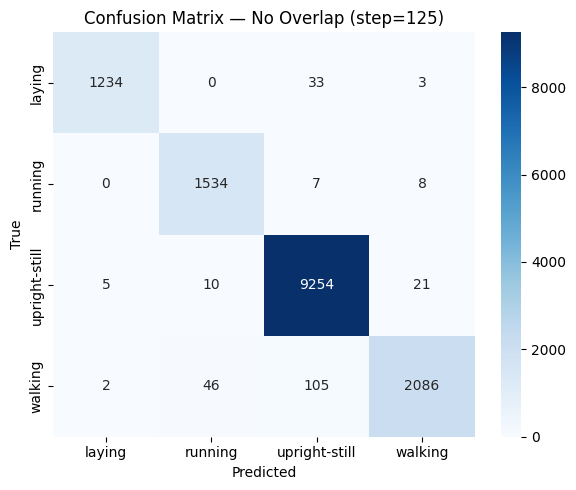

In [ ]:
cm_no_overlap = confusion_matrix(no_overlap_preds["true"], no_overlap_preds["pred"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_no_overlap, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — No Overlap (step=125)")
plt.tight_layout()
plt.show()

In [ ]:
print("=== Overlap ===")
print(classification_report(overlap_preds["true"], overlap_preds["pred"], target_names=CLASSES))

print("=== No Overlap ===")
print(classification_report(no_overlap_preds["true"], no_overlap_preds["pred"], target_names=CLASSES))

=== Overlap ===
               precision    recall  f1-score   support

       laying       0.99      0.97      0.98      3174
      running       0.99      0.99      0.99      3869
upright-still       0.99      1.00      0.99     23203
      walking       0.98      0.96      0.97      5603

     accuracy                           0.99     35849
    macro avg       0.99      0.98      0.98     35849
 weighted avg       0.99      0.99      0.99     35849

=== No Overlap ===
               precision    recall  f1-score   support

       laying       0.99      0.97      0.98      1270
      running       0.96      0.99      0.98      1549
upright-still       0.98      1.00      0.99      9290
      walking       0.98      0.93      0.96      2239

     accuracy                           0.98     14348
    macro avg       0.98      0.97      0.98     14348
 weighted avg       0.98      0.98      0.98     14348

